In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from scipy import stats

In [2]:
df=pd.read_csv(r"C:\Users\heman\Downloads\train.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.dropna(inplace=True)

In [5]:
df1=df[["Age","Fare","Survived"]]

In [6]:
df1

,Age,Fare,Survived
1,38.0,71.2833,1
3,35.0,53.1000,1
6,54.0,51.8625,0
10,4.0,16.7000,1
11,58.0,26.5500,1
...,...,...,...
871,47.0,52.5542,1
872,33.0,5.0000,0
879,56.0,83.1583,1
887,19.0,30.0000,1


In [7]:
x=df1[["Age","Fare"]]
y=df1["Survived"]

In [8]:
x

,Age,Fare
1,38.0,71.2833
3,35.0,53.1000
6,54.0,51.8625
10,4.0,16.7000
11,58.0,26.5500
...,...,...
871,47.0,52.5542
872,33.0,5.0000
879,56.0,83.1583
887,19.0,30.0000


In [9]:
y

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: Survived, Length: 183, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
x_train

,Age,Fare
331,45.5,28.5000
336,29.0,66.6000
193,3.0,26.0000
75,25.0,7.6500
248,37.0,52.5542
...,...,...
520,30.0,93.5000
92,46.0,61.1750
460,48.0,26.5500
872,33.0,5.0000


In [13]:
df1.isnull().sum()

Age         0
Fare        0
Survived    0
dtype: int64

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
DTC=DecisionTreeClassifier()
DTC.fit(x_train,y_train)


DecisionTreeClassifier()

In [16]:
y_pred=DTC.predict(x_test)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
print(accuracy_score(y_pred,y_test))

0.6486486486486487


In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=5,scoring="accuracy"))

0.6015015015015015

In [21]:
from sklearn.preprocessing import KBinsDiscretizer

In [22]:
kbin_age=KBinsDiscretizer(n_bins=15,encode="ordinal",strategy="quantile")
kbin_Fare=KBinsDiscretizer(n_bins=15,encode="ordinal",strategy="quantile")

In [23]:
from sklearn.compose import ColumnTransformer

In [24]:
trf=ColumnTransformer([
    ("kbin_age",kbin_age,[0]),
    ("kbin_Fare",kbin_Fare,[1])
])

In [25]:
transformed_x=trf.fit_transform(x)

In [26]:
transformed_x_train=trf.fit_transform(x_train)
transformed_x_test=trf.transform(x_test)

In [27]:
trf.named_transformers_["kbin_age"].bin_edges_

array([array([ 2.        , 15.66666667, 19.        , 23.        , 25.        ,
              29.        , 31.        , 34.66666667, 36.        , 37.        ,
              42.        , 47.        , 49.        , 54.        , 58.66666667,
              80.        ])                                                   ],
      dtype=object)

In [28]:
output=pd.DataFrame({"age":x_train["Age"],"trf_age":transformed_x_train[:,0],"Fare":x_train["Fare"],"trf_fare":transformed_x_train[:,1]})

In [29]:
output

,age,trf_age,Fare,trf_fare
331,45.5,10.0,28.5000,4.0
336,29.0,5.0,66.6000,8.0
193,3.0,0.0,26.0000,2.0
75,25.0,4.0,7.6500,0.0
248,37.0,9.0,52.5542,6.0
...,...,...,...,...
520,30.0,5.0,93.5000,11.0
92,46.0,10.0,61.1750,7.0
460,48.0,11.0,26.5500,3.0
872,33.0,6.0,5.0000,0.0


In [30]:
DTC1=DecisionTreeClassifier()
DTC1.fit(transformed_x_train,y_train)

DecisionTreeClassifier()

In [31]:
y_pred_modified=DTC1.predict(transformed_x_test)

In [32]:
print(accuracy_score(y_pred_modified,y_test))

0.5405405405405406


In [33]:
np.mean(cross_val_score(DTC1,transformed_x,y,scoring="accuracy"))

0.5740240240240241

In [34]:
def discretize(bins,Strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins,encode="ordinal",strategy=Strategy)
    kbin_Fare=KBinsDiscretizer(n_bins=bins,encode="ordinal",strategy=Strategy)
    trf=ColumnTransformer([("kbin_age",kbin_age,[0]),("kbin_Fare",kbin_Fare,[1])])
    
    transformed_x=trf.fit_transform(x)
    print(np.mean(cross_val_score(DTC1,transformed_x,y,scoring="accuracy")))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(transformed_x[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(transformed_x[:,1],color='red')
    plt.title("Fare")

    plt.show() 

0.6069069069069069


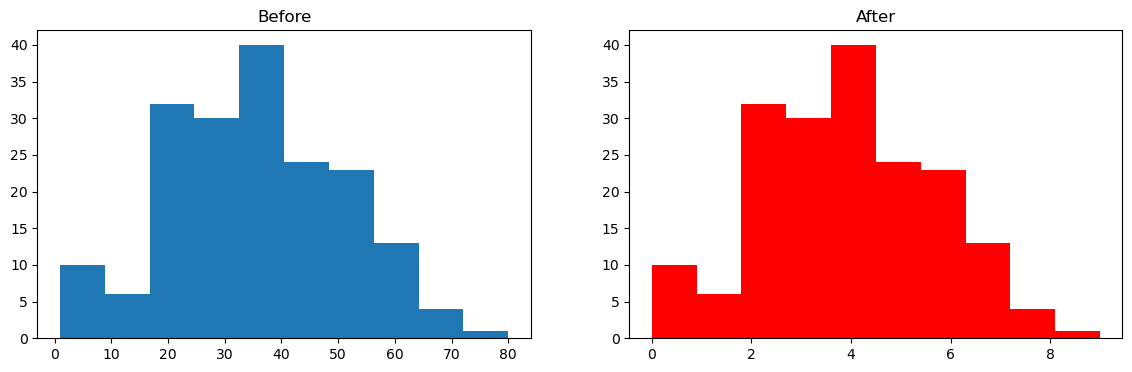

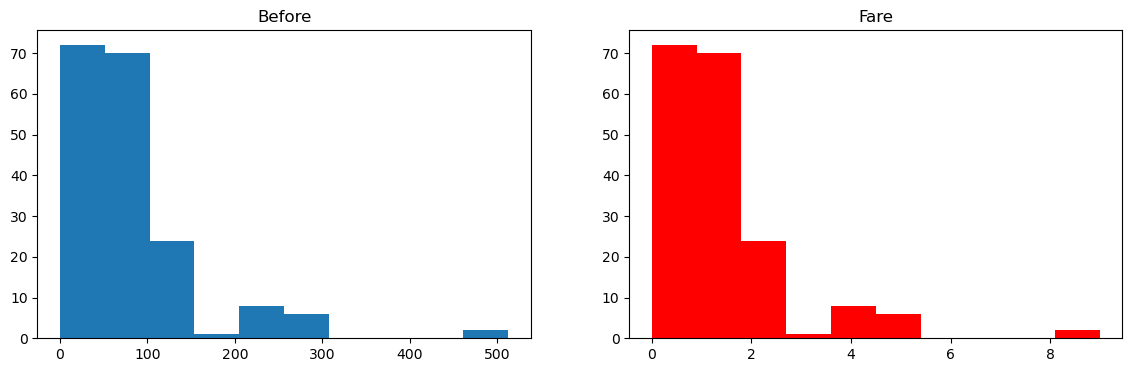

In [35]:
discretize(10,"uniform")

0.5515015015015015


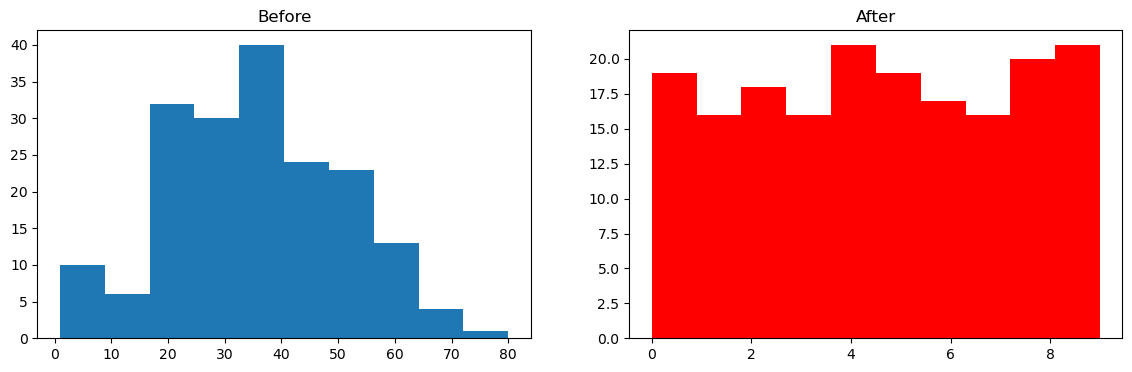

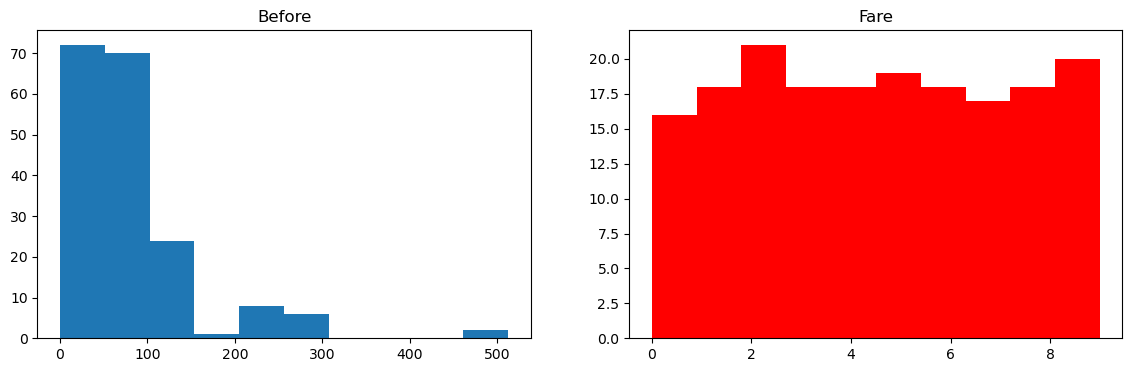

In [36]:
discretize(10,"quantile")

0.5683183183183182


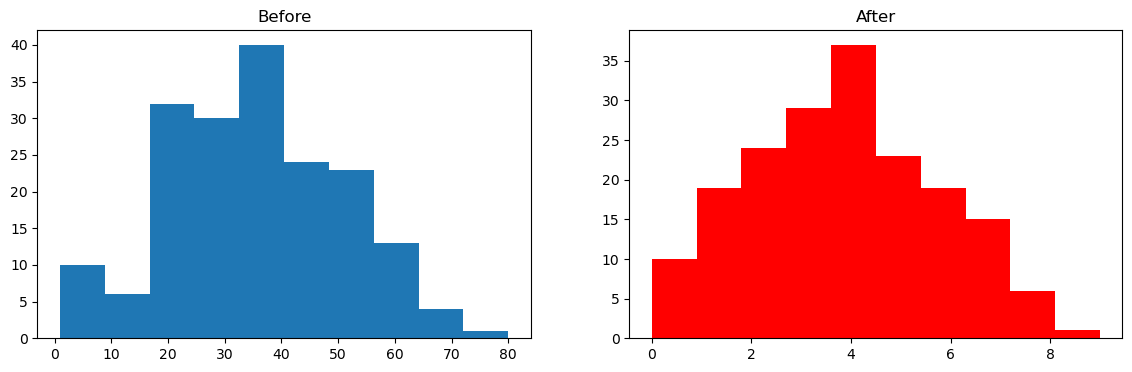

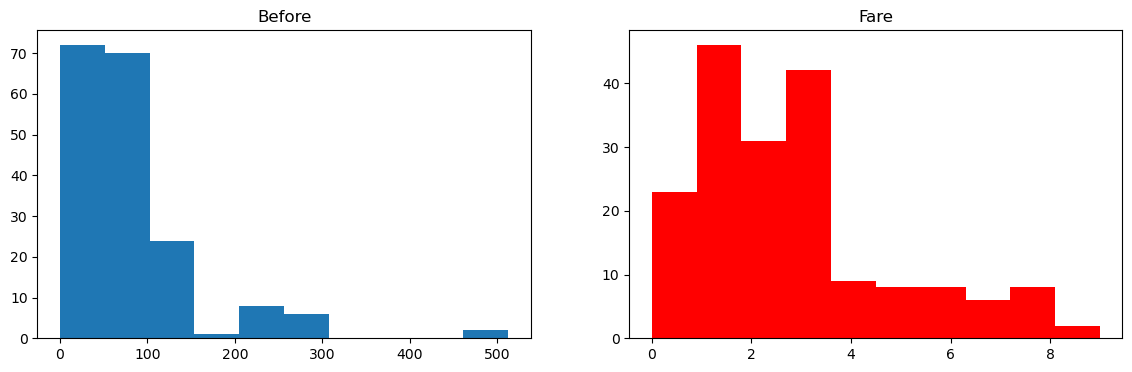

In [37]:
discretize(10,"kmeans")

In [38]:
from sklearn.preprocessing import Binarizer

In [39]:
df2=df[["Age","Fare","Survived","SibSp","Parch"]]

In [40]:
df2["family"]=df2["SibSp"]+df2["Parch"]

C:\Users\heman\AppData\Local\Temp\ipykernel_36612\2282939532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["family"]=df2["SibSp"]+df2["Parch"]


In [41]:
df2=df2.drop(columns=["SibSp","Parch"],axis=1)

In [42]:
df2

,Age,Fare,Survived,family
1,38.0,71.2833,1,1
3,35.0,53.1000,1,1
6,54.0,51.8625,0,0
10,4.0,16.7000,1,2
11,58.0,26.5500,1,0
...,...,...,...,...
871,47.0,52.5542,1,2
872,33.0,5.0000,0,0
879,56.0,83.1583,1,1
887,19.0,30.0000,1,0


In [43]:
x=df2[["Age","Fare","family"]]
y=df2["Survived"]

In [44]:
y

1      1
3      1
6      0
10     1
11     1
      ..
871    1
872    0
879    1
887    1
889    1
Name: Survived, Length: 183, dtype: int64

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
x_train.head()

,Age,Fare,family
331,45.5,28.5000,0
336,29.0,66.6000,1
193,3.0,26.0000,2
75,25.0,7.6500,0
248,37.0,52.5542,2


In [47]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(x_train,y_train)

y_pred = clf.predict(x_test)

accuracy_score(y_test,y_pred)

0.5675675675675675

In [48]:
from sklearn.preprocessing import Binarizer

In [49]:
trf=ColumnTransformer([("bin",Binarizer(copy=False),["family"])],remainder="passthrough")

In [50]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [52]:
clf1 = DecisionTreeClassifier()

clf1.fit(x_train_transformed,y_train)

y_pred = clf1.predict(x_test_transformed)

accuracy_score(y_test,y_pred)

0.5945945945945946